In [1]:
import pandas as pd
import folium
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# File path
file_path = '20250620_DecimalDegrees_clean.txt'

# Read the data into a DataFrame
df = pd.read_csv(file_path)

# Convert 'time' column to datetime format
df['time'] = pd.to_datetime(df['time'], format='%y-%m-%d %H:%M:%S')

# Set 'time' column as the index
df.set_index('time', inplace=True)

# Localize the naive datetime to UTC first  
df.index = df.index.tz_localize('UTC').tz_convert('America/Los_Angeles')

# Ensure that longitude values are negative
df['lon'] = -df['lon']

df.tail()
# print(df['lat'].tail())s
# print(df['lon'].tail())

# Function to convert DD.MMmm to decimal degrees
# From ChatGPT
def convert_to_decimal_degrees(coord):
    degrees = int(coord)  # Extract degrees (integer part)
    minutes = abs(coord - degrees) * 100  # Extract the minutes
    decimal_degrees = abs(degrees) + minutes / 60  # Convert minutes to decimal and add to degrees
    return decimal_degrees if coord >= 0 else -decimal_degrees  # Keep the sign for negative coordinates

# Apply the conversion function to the lat and lon columns
df['lat_decimal'] = df['lat'].apply(convert_to_decimal_degrees)
df['lon_decimal'] = df['lon'].apply(convert_to_decimal_degrees)

print(df[['lat_decimal', 'lon_decimal']])

                           lat_decimal  lon_decimal
time                                               
2025-06-20 19:41:40-07:00    34.147000  -121.359667
2025-06-20 19:41:42-07:00    34.147000  -121.359833
2025-06-20 19:41:43-07:00    34.147000  -121.359833
2025-06-20 19:41:45-07:00    34.147167  -121.359833
2025-06-20 19:41:46-07:00    34.147167  -121.359833
...                                ...          ...
2025-06-20 23:40:37-07:00    34.635833  -121.969500
2025-06-20 23:40:38-07:00    34.635833  -121.969500
2025-06-20 23:40:39-07:00    34.635833  -121.969500
2025-06-20 23:40:41-07:00    34.635833  -121.969667
2025-06-20 23:40:42-07:00    34.636000  -121.969667

[10605 rows x 2 columns]


In [4]:
# Create a Folium map centered at the first location
m = folium.Map(location=[df.iloc[0]['lat_decimal'], df.iloc[0]['lon_decimal']], zoom_start=16)

# Prepare the coordinates for the polyline
coordinates = df[['lat_decimal', 'lon_decimal']].values.tolist()

# Add a line connecting the points
folium.PolyLine(coordinates, color='blue', weight=2.5, opacity=1).add_to(m)

# Save map to an HTML file
m.save('20250620_DecimalDegrees.html')


In [5]:
print('Power-On Duration')
duration = df.index[-1]-df.index[0]
print(duration)

# Compute time differences
time_diffs = df.index.to_series().diff().dropna()

# Compute average duration
avg_duration = time_diffs.mean()

print(f"Platform Sampled at an average {avg_duration.total_seconds():.2f} Hz")


Power-On Duration
0 days 03:59:02
Platform Sampled at an average 1.35 Hz


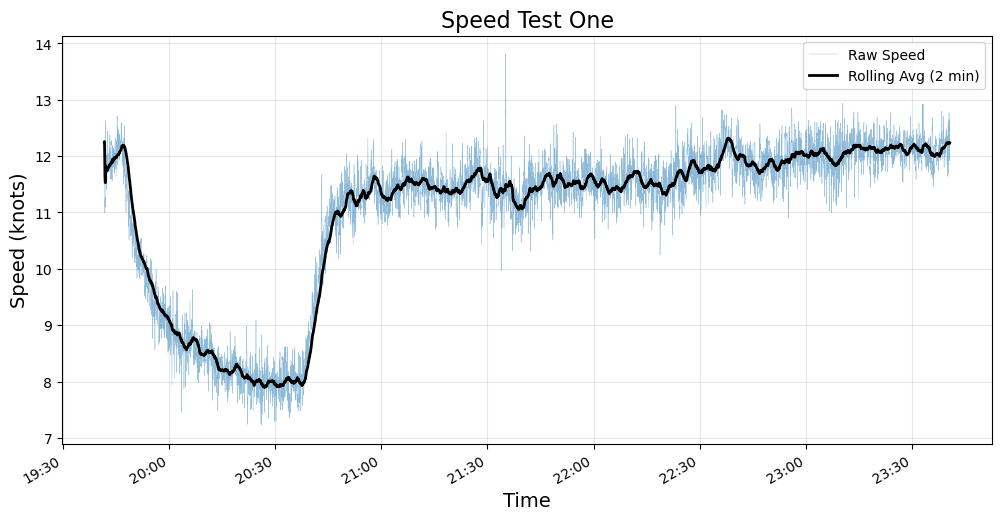

In [72]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pytz

# Convert m/s to knots
df['speed_knots'] = (df['speed'] * 1.15) - 1.2

# Rolling average over 2 minutes (adjust as needed)
df['speed_knots_roll'] = df['speed_knots'].rolling('2min').mean()

# Set up the plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df.index, df['speed_knots'], label='Raw Speed', alpha=0.5, linewidth=0.3)
ax.plot(df.index, df['speed_knots_roll'], label='Rolling Avg (2 min)', color='black', linewidth=2)

# Use local timezone-aware formatter
local_tz = pytz.timezone('America/Los_Angeles')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=local_tz))

# Rotate x labels and finish formatting
fig.autofmt_xdate()
ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Speed (knots)', fontsize=14)
ax.set_title('Speed Test One', fontsize=16)
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()



C:\Users\sscop\AppData\Local\Temp\ipykernel_35348\1958554751.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


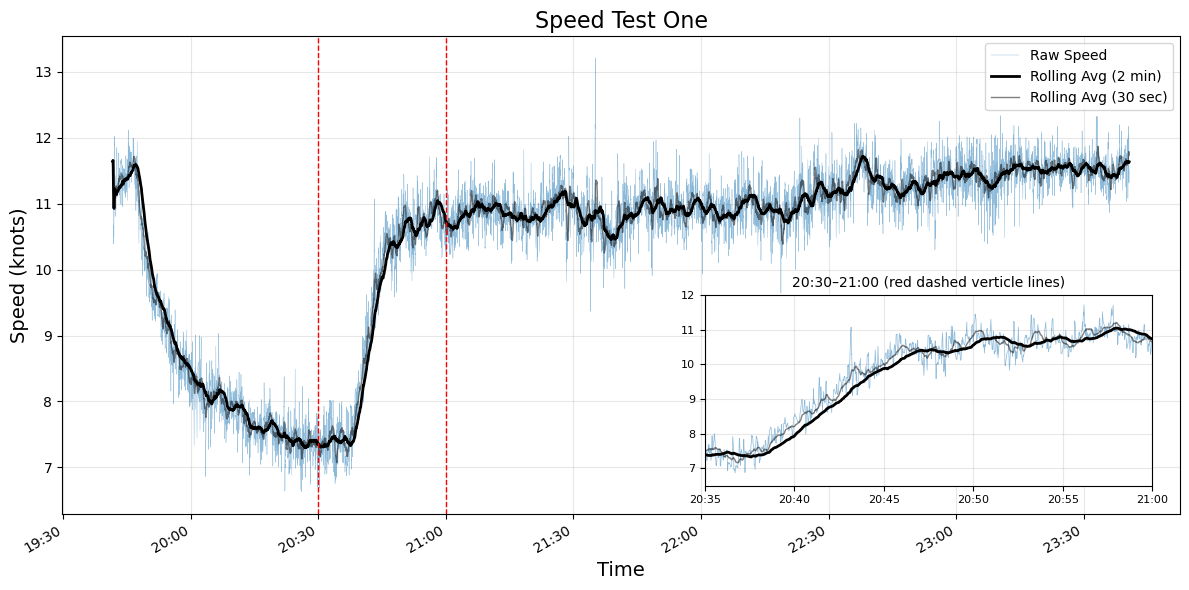

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pytz
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Convert m/s to knots and adjust
df['speed_knots'] = (df['speed'] * 1.15) - 1.8
df['speed_knots_roll'] = df['speed_knots'].rolling('2min').mean()
df['speed_knots_roll_30'] = df['speed_knots'].rolling('30s').mean()

# Set up the main plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df.index, df['speed_knots'], label='Raw Speed', alpha=0.5, linewidth=0.3)
ax.plot(df.index, df['speed_knots_roll'], label='Rolling Avg (2 min)', color='black', linewidth=2)
ax.plot(df.index, df['speed_knots_roll_30'], label='Rolling Avg (30 sec)', alpha=0.5, linewidth=1,color='black')


# Format main x-axis
local_tz = pytz.timezone('America/Los_Angeles')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=local_tz))
fig.autofmt_xdate()

# Add inset: 20:30–21:00
inset_ax = inset_axes(ax, width="40%", height="40%", loc='lower right', borderpad=2)

# Filter data for inset
start_time = df.index[0].replace(hour=20, minute=35, second=0)
end_time = df.index[0].replace(hour=21, minute=00, second=0)
mask = (df.index >= start_time) & (df.index <= end_time)

# Plot inset
inset_ax.plot(df.index[mask], df['speed_knots'][mask], alpha=0.5, linewidth=0.5)
inset_ax.plot(df.index[mask], df['speed_knots_roll_30'][mask], color='black', alpha=0.5,linewidth=1)
inset_ax.plot(df.index[mask], df['speed_knots_roll'][mask], color='black', linewidth=2)


inset_ax.grid(True, alpha=0.3)
inset_ax.set_ylim(6.5,12)

# Format inset x-axis
inset_ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=local_tz))
inset_ax.set_xlim(start_time, end_time)
inset_ax.set_title('20:30–21:00 (red dashed verticle lines)', fontsize=10)
inset_ax.tick_params(labelsize=8)

ax.axvline(pd.Timestamp('2025-06-20 20:30').tz_localize('America/Los_Angeles'), color='red', linestyle='--', linewidth=1)
ax.axvline(pd.Timestamp('2025-06-20 21:00').tz_localize('America/Los_Angeles'), color='red', linestyle='--', linewidth=1)
# ax.axhline(10.8)

# Finalize main plot
ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Speed (knots)', fontsize=14)
ax.set_title('Speed Test One', fontsize=16)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('WXStation_speedTestOne_30s_120s.jpg',dpi=600)
plt.show()


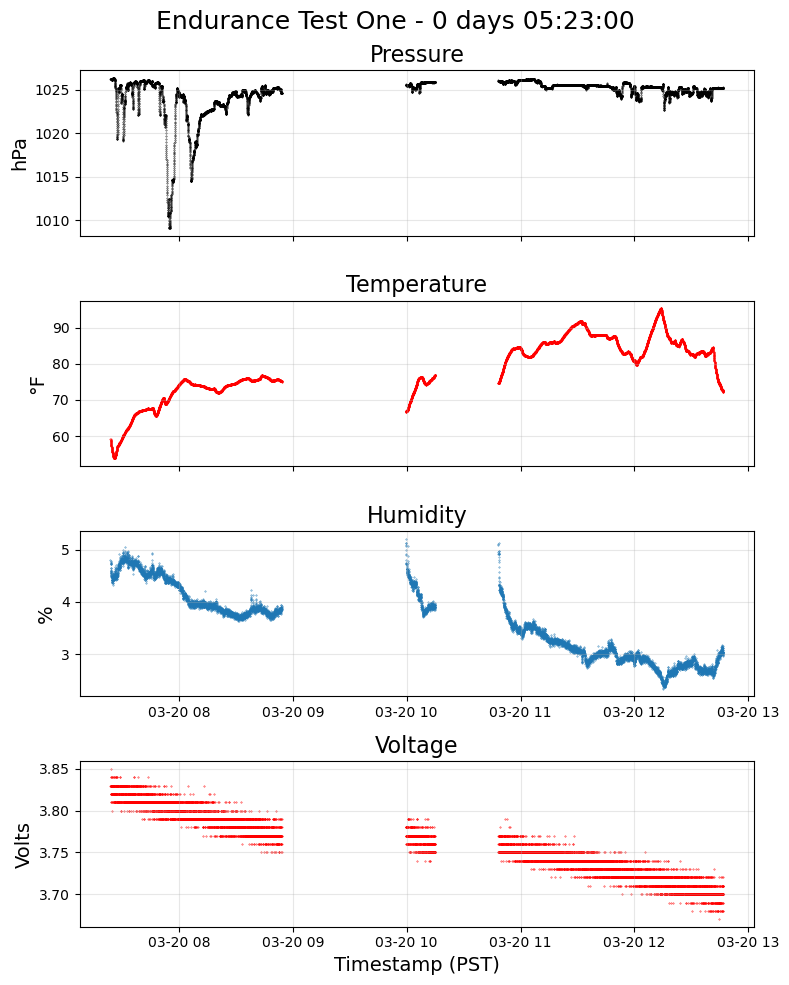

In [27]:
plt.figure(figsize=(8, 10))

size=0.1

plt.subplot(4, 1, 1)
plt.scatter(df.index, df['pressurehPa'],s=size,color='black',linewidth=1)
plt.title('Pressure', fontsize=16)
plt.ylabel('hPa', fontsize=14)
plt.grid(True, alpha=0.3)
plt.gca().set_xticklabels([])  # Remove x-tick labels for the first plot

plt.subplot(4, 1, 2)
plt.scatter(df.index, df['tempF'],s=size,color='red',linewidth=1)
plt.title('Temperature', fontsize=16)
plt.ylabel('°F', fontsize=14)
plt.grid(True, alpha=0.3)
plt.gca().set_xticklabels([])  # Remove x-tick labels for the second plot

plt.subplot(4, 1, 3)
plt.scatter(df.index, df['humidity'],s=size,linewidth=1)
plt.title('Humidity', fontsize=16)
plt.ylabel('%', fontsize=14)
# plt.xlabel('Timestamp (PST)', fontsize=14)
plt.grid(True, alpha=0.3)

plt.subplot(4, 1, 4)
plt.scatter(df.index, df['vBat'],s=size,color='red')
plt.title('Voltage', fontsize=16)
plt.ylabel('Volts', fontsize=14)
plt.xlabel('Timestamp (PST)', fontsize=14)
plt.grid(True, alpha=0.3)

plt.suptitle(f'Endurance Test One - {duration}',fontsize=18)
plt.tight_layout()
# plt.savefig('20250313_endurance_test1.jpg',dpi=600)
plt.show()
